<a href="https://colab.research.google.com/github/t114c75034/AI-Security_0511-Preclass-HW/blob/main/%E3%80%8CDNN_workshop_1_ipynb%E3%80%8D_114C75034.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Code and Example reference

Reference Deep Learning with Python, Second Edition.


3D tensor: Dimentions 3 Shape (60000, 28, 28) Dtype uint8 
Train Lables [5 0 4 ... 5 6 8]
2D tensor (28, 28)


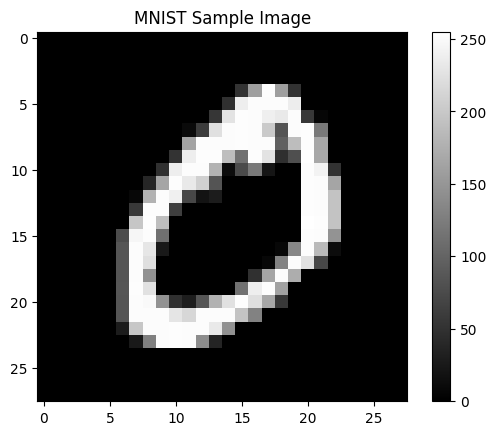

print a pixel 0 


In [56]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()
print(f"3D tensor: Dimentions {train_images.ndim} Shape {train_images.shape} Dtype {train_images.dtype} ")
print(f"Train Lables {train_labels}")
single_image = train_images[1]
print(f"2D tensor {single_image.shape}")
plt.imshow(single_image, cmap='gray')
plt.title('MNIST Sample Image')
plt.colorbar()
plt.show()
print(f"print a pixel {single_image[14,14]} ")

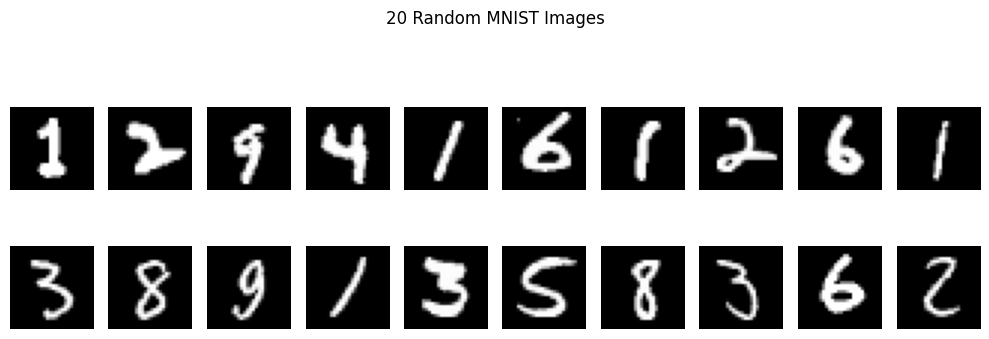

In [57]:
# Get total images index
total_index = train_images.shape[0]

# Select 20 random indices
random_indices = np.random.choice(total_index, size=20, replace=False)

# Create figure for plotting
fig, axes = plt.subplots(2, 10, figsize=(10, 4))

# Reshape images and plot them
for i, idx in enumerate(random_indices):
    image = train_images[idx].reshape(28, 28)
    axes[int(i / 10), i % 10].imshow(image, cmap="gray")
    axes[int(i / 10), i % 10].axis("off")

# Add title
fig.suptitle("20 Random MNIST Images", fontsize=12)

# Show plot
plt.tight_layout()
plt.show()

In [58]:
from tensorflow import keras
from tensorflow.keras import layers
# import packages for handling upload image
from tensorflow.keras.preprocessing.image import load_img
import os
import numpy as np

# --- CNN Model Definition ---
model = keras.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)), # First Convolutional layer
    layers.MaxPooling2D((2, 2)), # Max Pooling to reduce dimensionality
    layers.Conv2D(64, (3, 3), activation='relu'), # Second Convolutional layer
    layers.MaxPooling2D((2, 2)), # Max Pooling
    layers.Flatten(), # Flatten the 2D output to 1D for the Dense layers
    layers.Dense(128, activation='relu'), # Dense layer
    layers.Dense(10, activation='softmax') # Output layer
])

model.compile(optimizer=keras.optimizers.RMSprop(1e-3), # Adjusted learning rate for CNN
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# --- Manipulate the dataset for CNN input ---
# Reshape images to (batch, height, width, channels) for CNN
train_images_cnn = train_images.reshape((60000, 28, 28, 1))
train_images_cnn = train_images_cnn.astype("float32") / 255
test_images_cnn = test_images.reshape((10000, 28, 28, 1))
test_images_cnn = test_images_cnn.astype("float32") / 255

# Start to train with CNN-compatible data
model.fit(train_images_cnn, train_labels,
          epochs=10, # Increased epochs for CNN training
          batch_size=64, # Adjusted batch size for CNN
          validation_split=0.2)

# Basic evaluate
test_loss, test_acc = model.evaluate(test_images_cnn, test_labels)
print(f"test_acc: {test_acc}")

# Evaluate recall, precision, F1, AUC
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np

# Make predictions on the test set
predictions = model.predict(test_images_cnn)

# Get the predicted classes (the one with the highest probability)
predicted_classes = np.argmax(predictions, axis=1)

# Print classification report (includes Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(test_labels, predicted_classes))

# Calculate and print AUC (One-vs-Rest)
auc_score = roc_auc_score(test_labels, predictions, multi_class='ovr')
print(f"\nAUC (One-vs-Rest): {auc_score}")


# Evaluate single one image
test_digits = test_images_cnn[0:10] # Use CNN-compatible test images
predictions = model.predict(test_digits)
print(f"pick first 10 for Evaluatoin: {predictions[0]} max {predictions[0].argmax()}")
print(f"Lable of max argument: {test_labels[0]} ")

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 56ms/step - accuracy: 0.9456 - loss: 0.1784 - val_accuracy: 0.9783 - val_loss: 0.0752
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 42s 56ms/step - accuracy: 0.9841 - loss: 0.0509 - val_accuracy: 0.9856 - val_loss: 0.0500
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 43s 58ms/step - accuracy: 0.9895 - loss: 0.0331 - val_accuracy: 0.9885 - val_loss: 0.0379
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 55ms/step - accuracy: 0.9918 - loss: 0.0254 - val_accuracy: 0.9896 - val_loss: 0.0370
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9939 - loss: 0.0180 - val_accuracy: 0.9915 - val_loss: 0.0348
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 82s 55ms/step - accuracy: 0.9960 - loss: 0.0134 - val_accuracy: 0.9905 - val_loss: 0.0373
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9968 - loss: 0.0101 - val_accuracy: 0.9905 - val_loss: 0.0420
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9977 - loss: 0.0068 - 

### Upload Your Own Handwriting Digit Image

To recognize your own digit, please upload an image file (e.g., `digit.jpg` or `digit.png`) to your Colab environment. You can do this by clicking the 'Files' icon on the left sidebar, then 'Upload to session storage'. Make sure the image is a clear, black and white image of a single digit, preferably 28x28 pixels, though the code will resize it.

After uploading, update the `file_path` variable in the next code cell to point to your uploaded image.

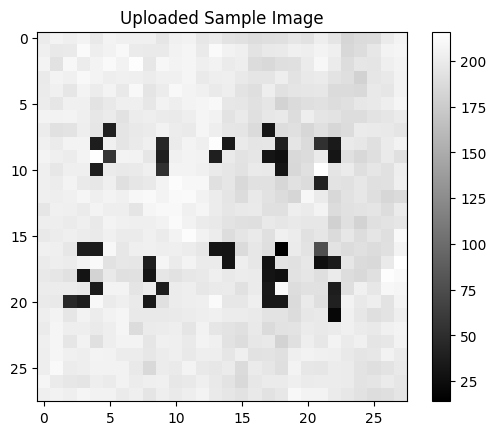

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
Model's raw prediction (probabilities for each digit): [6.2545887e-03 4.3451381e-03 4.8788311e-03 1.2912964e-03 8.0827270e-03
 4.0052202e-02 8.6366808e-01 3.3166114e-06 6.3647687e-02 7.7761188e-03]
The model predicts this digit is: 6


In [59]:
from tensorflow.keras.preprocessing.image import load_img
import matplotlib.pyplot as plt
import numpy as np
import os

# IMPORTANT: Change this path to your uploaded image file
file_path = '/content/IMG_0090.jpg'  # Example: '/content/my_digit.png' or '/content/digit.jpg'

# Check if the file exists
if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}. Please upload your image and update the file_path variable.")
else:
    # Load the image using Keras preprocessing
    image = load_img(file_path, color_mode = "grayscale", target_size=(28, 28))

    plt.imshow(image, cmap='gray')
    plt.title('Uploaded Sample Image')
    plt.colorbar()
    plt.show()

    # Convert to array and preprocess for the model (for CNN, reshape to (1, 28, 28, 1))
    image_array = np.array(image)
    image_array = image_array.reshape((1, 28, 28, 1)) # Reshape for CNN
    image_array = image_array.astype("float32") / 255 # Normalize pixel values

    # Make a prediction with the trained model
    predictions_on_user_image = model.predict(image_array)
    predicted_digit = predictions_on_user_image[0].argmax()

    print(f"Model's raw prediction (probabilities for each digit): {predictions_on_user_image[0]}")
    print(f"The model predicts this digit is: {predicted_digit}")

### Recognizing Multiple Digits in an Image

To recognize multiple digits in a single image, we need to:

1.  **Install necessary libraries**: `scikit-image` for image processing.
2.  **Load the image**: Load the user's image.
3.  **Pre-process the image**: Convert to grayscale, invert colors (if needed, as MNIST is white digits on black background), and apply thresholding to get a binary image.
4.  **Find contours**: Identify individual digit regions using contour detection.
5.  **Extract and resize each digit**: Crop each identified digit, resize it to 28x28, and prepare it for the model.
6.  **Predict each digit**: Pass each prepared digit to the pre-trained `model`.
7.  **Display results**: Show the original image with bounding boxes around detected digits and their predicted labels.

In [60]:
# Install scikit-image for advanced image processing
!pip install scikit-image

# Import necessary libraries
from skimage.io import imread
from skimage.transform import resize
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu
from PIL import Image
import matplotlib.patches as patches

Now, let's specify the image path for your multi-digit image. Make sure the image is uploaded to your Colab environment.

Colors inverted (manual override). Digits should now be white on a black background.


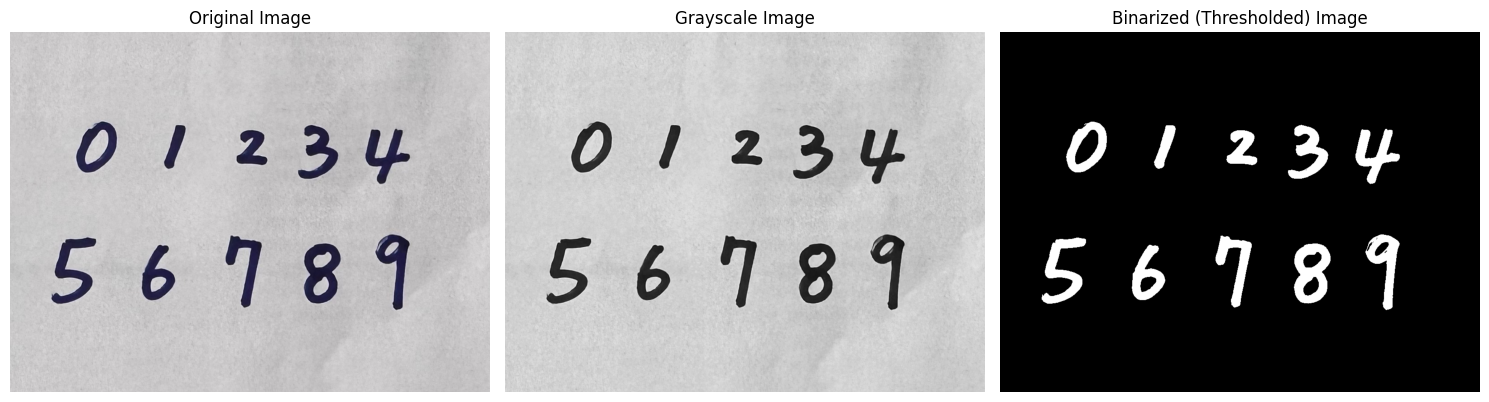

Detected digits and their predictions:


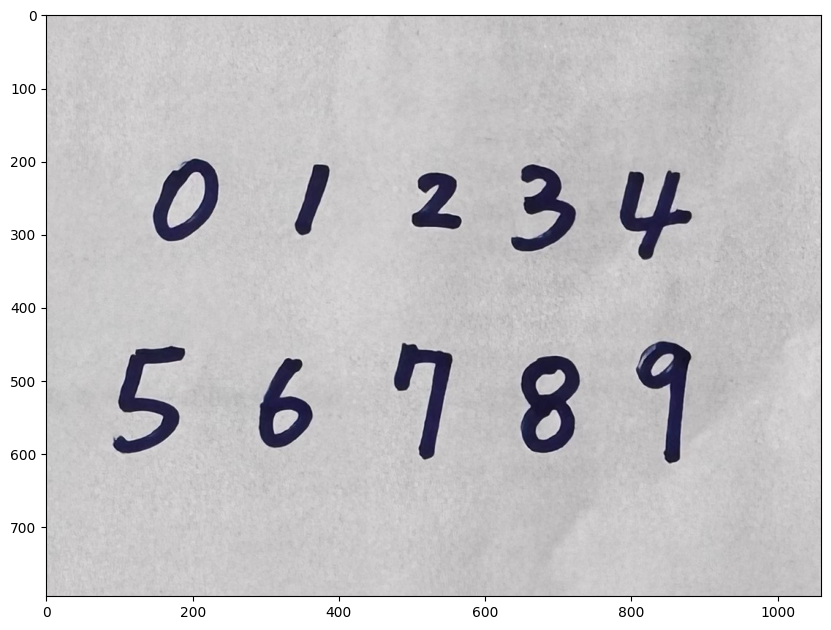

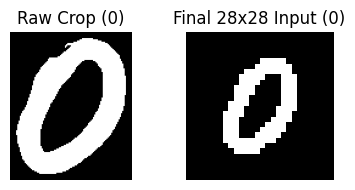

  - Digit at (141,193) to (241,315): Predicted as 0


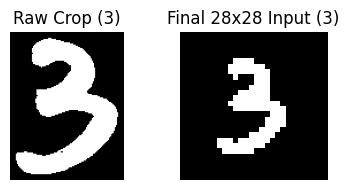

  - Digit at (631,200) to (730,329): Predicted as 3


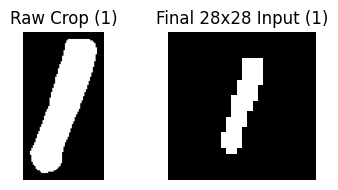

  - Digit at (335,201) to (393,307): Predicted as 1


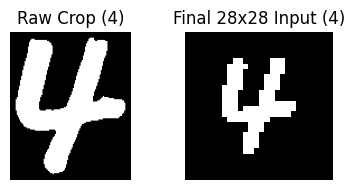

  - Digit at (780,209) to (888,341): Predicted as 4


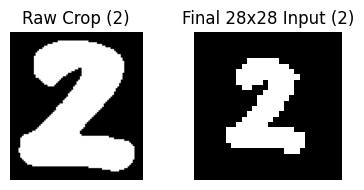

  - Digit at (495,212) to (573,299): Predicted as 2


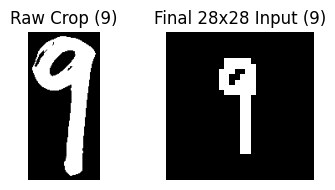

  - Digit at (802,442) to (888,619): Predicted as 9


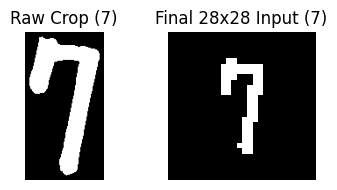

  - Digit at (471,444) to (561,614): Predicted as 7


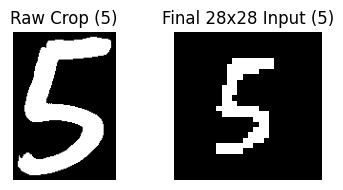

  - Digit at (87,449) to (195,605): Predicted as 5


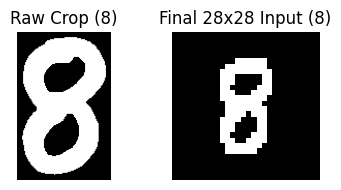

  - Digit at (644,462) to (735,605): Predicted as 8


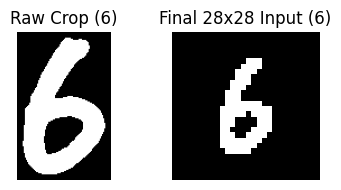

  - Digit at (286,465) to (370,597): Predicted as 6


<Figure size 640x480 with 0 Axes>

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from skimage.measure import label, regionprops
from skimage.filters import threshold_otsu
from PIL import Image
import matplotlib.patches as patches
import os
from skimage.morphology import binary_dilation, disk # Import for dilation

# IMPORTANT: Set this path to your uploaded image file containing multiple digits
multi_digit_image_path = '/content/IMG_0090.jpg' # You can change this if you upload a different image

# --- New: Control for manual color inversion (absolute control) ---
invert_colors_manually = True # Set to True to ALWAYS invert colors (dark digits on light background -> white on black)
                               # Set to False to NEVER invert colors (assuming digits are already white on black)

# --- New: Control for optional digit dilation ---
should_dilate = False # Set to True to apply dilation (thicken digits), False otherwise

if not os.path.exists(multi_digit_image_path):
    print(f"Error: File not found at {multi_digit_image_path}. Please ensure you have uploaded the image.")
else:
    # Load the image
    image_original = imread(multi_digit_image_path)

    # Convert to grayscale if it's a color image
    if image_original.ndim == 3:
        image_gray = np.mean(image_original, axis=2)
    else:
        image_gray = image_original

    # Apply inversion based on manual setting (absolute control)
    if invert_colors_manually:
        image_inverted = 255 - image_gray
        print("Colors inverted (manual override). Digits should now be white on a black background.")
    else:
        image_inverted = image_gray
        print("Colors NOT inverted (manual override). Digits should already be white on a black background.")

    # Apply Otsu's thresholding to get a binary image from the inverted image
    thresh = threshold_otsu(image_inverted)
    image_binary = image_inverted > thresh

    # Display the preprocessed image
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image_original, cmap='gray')
    axes[0].set_title('Original Image')
    axes[0].axis('off')

    axes[1].imshow(image_gray, cmap='gray')
    axes[1].set_title('Grayscale Image')
    axes[1].axis('off')

    axes[2].imshow(image_binary, cmap='gray')
    axes[2].set_title('Binarized (Thresholded) Image')
    axes[2].axis('off')
    plt.tight_layout()
    plt.show()

    # Label connected components (potential digits)
    label_image = label(image_binary)

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(image_original, cmap='gray') # Show original for context

    print("Detected digits and their predictions:")
    for region in regionprops(label_image):
        # Filter out small regions that are likely noise or too large (e.g., the whole image)
        # Adjusted thresholds: minimum area 100 to reduce noise, maximum area to avoid entire image
        if region.area < 100 or region.area > (image_original.shape[0] * image_original.shape[1]) / 4:
            continue

        # Get bounding box coordinates
        minr, minc, maxr, maxc = region.bbox

        # --- Add a small padding to the bounding box to ensure full digit capture ---
        padding = 5 # pixels
        minr = max(0, minr - padding)
        minc = max(0, minc - padding)
        maxr = min(image_binary.shape[0], maxr + padding)
        maxc = min(image_binary.shape[1], maxc + padding)

        # Extract the digit image from the *binarized* image (0.0 or 1.0)
        digit_crop_binary = image_binary[minr:maxr, minc:maxc].astype(np.float32)

        # Skip if the crop is empty or too small after cropping
        if digit_crop_binary.shape[0] == 0 or digit_crop_binary.shape[1] == 0:
            continue

        # --- Apply optional dilation to thicken the digit strokes ---
        if should_dilate:
            selem = disk(1) # 1-pixel radius disk-shaped structuring element
            digit_crop_binary = binary_dilation(digit_crop_binary, selem).astype(np.float32)
            # print(f"  - Dilation applied for digit at ({minc},{minr})") # Optional: uncomment for verbose output

        # --- Improved digit preprocessing (maintain aspect ratio and center) ---
        # Calculate aspect ratio
        height = digit_crop_binary.shape[0]
        width = digit_crop_binary.shape[1]

        # Determine scaling factor to fit into a 20x20 box (leaving 4 pixels border on each side for 28x28)
        if height > width:
            scale_factor = 20.0 / height
        else:
            scale_factor = 20.0 / width

        new_height = int(height * scale_factor)
        new_width = int(width * scale_factor)

        # Resize the digit crop while maintaining aspect ratio.
        # The output values will be in 0.0-1.0 range, potentially with anti-aliasing gray values.
        resized_digit_raw = resize(digit_crop_binary, (new_height, new_width),
                                    anti_aliasing=True, mode='constant', cval=0.0)

        # --- Re-binarize the resized digit to ensure it's strictly 0.0 or 1.0 ---
        resized_digit_binary = (resized_digit_raw > 0.5).astype(np.float32)

        # Create a new 28x28 black canvas (0.0 for black, 1.0 for white)
        digit_canvas_normalized = np.zeros((28, 28), dtype=np.float32)

        # Calculate paste position to center the digit
        start_row = (28 - new_height) // 2
        start_col = (28 - new_width) // 2

        # Paste the re-binarized, resized digit onto the canvas
        digit_canvas_normalized[start_row:start_row + new_height,
                               start_col:start_col + new_width] = resized_digit_binary

        # For display, scale to 0-255 and convert to uint8
        digit_canvas_display = (digit_canvas_normalized * 255.0).astype(np.uint8)

        # For the model (CNN), reshape to (1, 28, 28, 1)
        digit_processed = digit_canvas_normalized.reshape(1, 28, 28, 1)

        # Predict the digit
        prediction = model.predict(digit_processed, verbose=0)
        predicted_digit = np.argmax(prediction[0])

        # --- NEW: Debugging displays for each digit ---
        fig_debug, axes_debug = plt.subplots(1, 2, figsize=(4, 2))

        # Plot 1: Raw Binary Crop (after dilation if applied)
        axes_debug[0].imshow(digit_crop_binary, cmap='gray')
        axes_debug[0].set_title(f"Raw Crop ({predicted_digit})")
        axes_debug[0].axis('off')

        # Plot 2: Final 28x28 Input to Model
        axes_debug[1].imshow(digit_canvas_display, cmap='gray')
        axes_debug[1].set_title(f"Final 28x28 Input ({predicted_digit})")
        axes_debug[1].axis('off')

        plt.tight_layout()
        plt.show()
        # --- End Debugging displays ---

        # Draw bounding box and label
        rect = patches.Rectangle((minc, minr), maxc - minc, maxr - minr,
                                 linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
        ax.text(minc, minr - 5, str(predicted_digit),
                color='red', fontsize=12, fontweight='bold')

        print(f"  - Digit at ({minc},{minr}) to ({maxc},{maxr}): Predicted as {predicted_digit}")

    ax.set_title('Detected Digits with Predictions')
    ax.axis('off')
    plt.tight_layout()
    plt.show()